In [1]:
import xarray as xr

temp_ds = xr.open_dataset(
    r"C:\OceanF\data\raw\SubsurfaceTemp\SubsurfaceTemp.nc"
)

print(temp_ds)

<xarray.Dataset> Size: 12GB
Dimensions:    (time: 184, depth: 36, latitude: 301, longitude: 721)
Coordinates:
  * time       (time) datetime64[ns] 1kB 2025-07-01 2025-07-02 ... 2025-12-31
  * depth      (depth) float32 144B 0.494 1.541 2.646 ... 763.3 902.3 1.062e+03
  * latitude   (latitude) float32 1kB 5.0 5.083 5.167 5.25 ... 29.83 29.92 30.0
  * longitude  (longitude) float32 3kB 45.0 45.08 45.17 ... 104.8 104.9 105.0
Data variables:
    thetao     (time, depth, latitude, longitude) float64 12GB ...
Attributes: (12/25)
    Conventions:               CF-1.4
    bulletin_date:             2021-07-07 00:00:00
    bulletin_type:             operational
    comment:                   CMEMS product
    domain_name:               GL12
    easting:                   longitude
    ...                        ...
    references:                http://www.mercator-ocean.fr
    source:                    MERCATOR GLORYS12V1
    title:                     daily mean fields from Global Ocean Phys

In [2]:
xr.open_dataset(..., chunks=...)

ValueError: did not find a match in any of xarray's currently installed IO backends ['netcdf4', 'h5netcdf', 'scipy', 'zarr']. Consider explicitly selecting one of the installed engines via the ``engine`` parameter, or installing additional IO dependencies, see:
https://docs.xarray.dev/en/stable/getting-started-guide/installing.html
https://docs.xarray.dev/en/stable/user-guide/io.html

In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Paths
RAW_FILE = Path(r"C:\OceanF\data\raw\SubsurfaceTemp\SubsurfaceTemp.nc")
EDA_DIR = Path(r"C:\OceanF\data\eda\SubsurfaceTemp")

EDA_DIR.mkdir(parents=True, exist_ok=True)

print("Raw file:", RAW_FILE)
print("EDA directory:", EDA_DIR)

Raw file: C:\OceanF\data\raw\SubsurfaceTemp\SubsurfaceTemp.nc
EDA directory: C:\OceanF\data\eda\SubsurfaceTemp


In [2]:
ds = xr.open_dataset(
    RAW_FILE,
    chunks={
        "time": 1,
        "depth": 1,
        "latitude": 301,
        "longitude": 721
    }
)

print(ds)

<xarray.Dataset> Size: 12GB
Dimensions:    (time: 184, depth: 36, latitude: 301, longitude: 721)
Coordinates:
  * time       (time) datetime64[ns] 1kB 2025-07-01 2025-07-02 ... 2025-12-31
  * depth      (depth) float32 144B 0.494 1.541 2.646 ... 763.3 902.3 1.062e+03
  * latitude   (latitude) float32 1kB 5.0 5.083 5.167 5.25 ... 29.83 29.92 30.0
  * longitude  (longitude) float32 3kB 45.0 45.08 45.17 ... 104.8 104.9 105.0
Data variables:
    thetao     (time, depth, latitude, longitude) float64 12GB dask.array<chunksize=(1, 1, 301, 721), meta=np.ndarray>
Attributes: (12/25)
    Conventions:               CF-1.4
    bulletin_date:             2021-07-07 00:00:00
    bulletin_type:             operational
    comment:                   CMEMS product
    domain_name:               GL12
    easting:                   longitude
    ...                        ...
    references:                http://www.mercator-ocean.fr
    source:                    MERCATOR GLORYS12V1
    title:         

In [3]:
thetao = ds["thetao"]

print("Variable:", thetao.name)
print("Dimensions:", thetao.dims)
print("Shape:", thetao.shape)
print("Units:", thetao.attrs.get("units"))
print("Standard name:", thetao.attrs.get("standard_name"))

Variable: thetao
Dimensions: ('time', 'depth', 'latitude', 'longitude')
Shape: (184, 36, 301, 721)
Units: degrees_C
Standard name: sea_water_potential_temperature


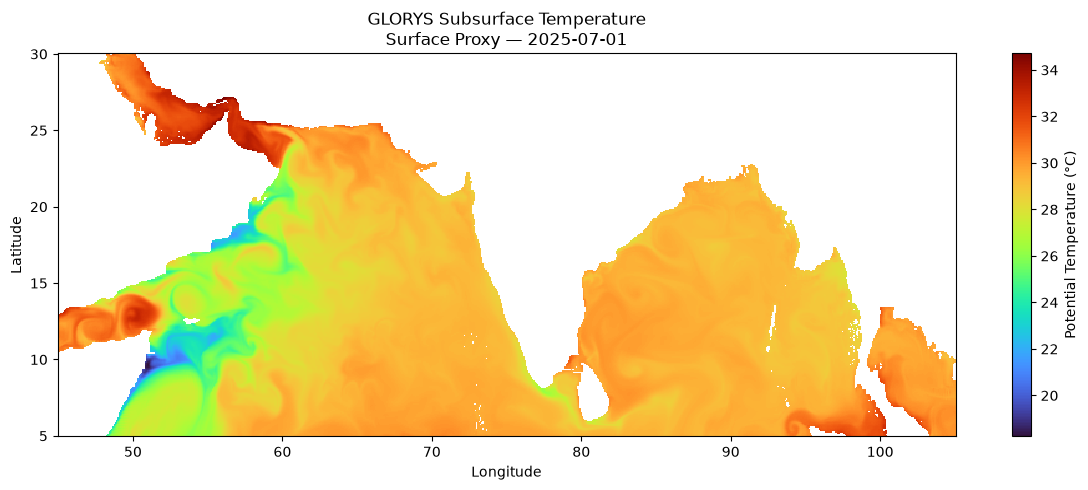

In [4]:
surface_temp = thetao.isel(
    time=0,
    depth=0
).load()

plt.figure(figsize=(12, 5))

surface_temp.plot(
    cmap="turbo",
    cbar_kwargs={"label": "Potential Temperature (°C)"}
)

plt.title(
    f"GLORYS Subsurface Temperature\n"
    f"Surface Proxy — {str(ds.time.values[0])[:10]}"
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.tight_layout()

plt.savefig(
    EDA_DIR / "surface_temperature_day1.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

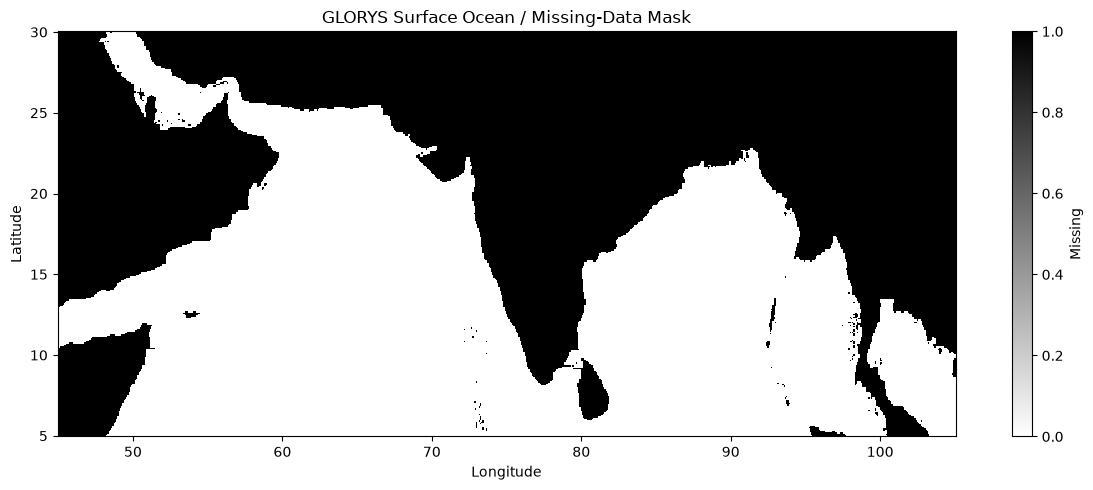

In [5]:
surface_mask = surface_temp.isnull()

plt.figure(figsize=(12, 5))

surface_mask.plot(
    cmap="gray_r",
    cbar_kwargs={"label": "Missing"}
)

plt.title("GLORYS Surface Ocean / Missing-Data Mask")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.tight_layout()

plt.savefig(
    EDA_DIR / "surface_missing_mask.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

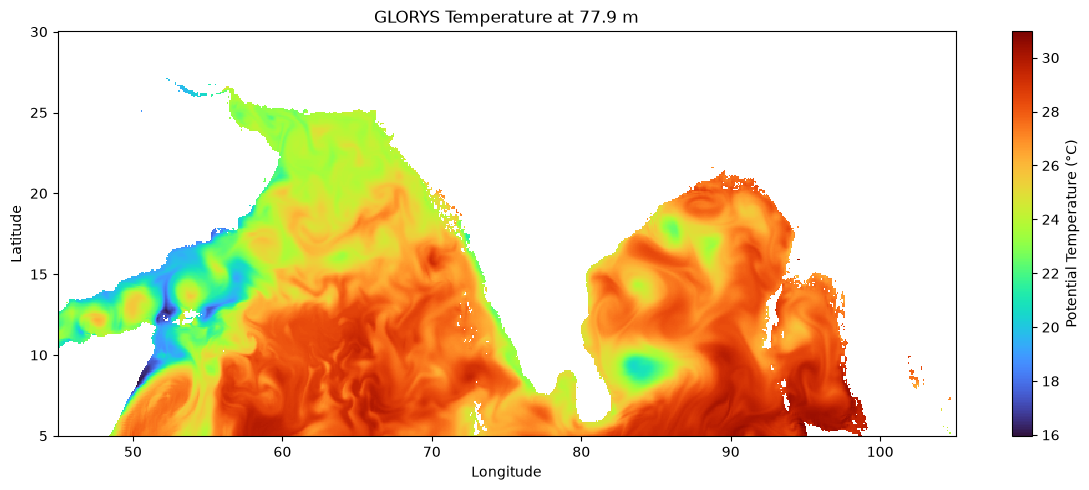

In [6]:
deep_temp = thetao.isel(
    time=0,
    depth=20
).load()

plt.figure(figsize=(12, 5))

deep_temp.plot(
    cmap="turbo",
    cbar_kwargs={"label": "Potential Temperature (°C)"}
)

plt.title(
    f"GLORYS Temperature at {float(ds.depth.values[20]):.1f} m"
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.tight_layout()

plt.savefig(
    EDA_DIR / "deep_temperature_mask_check.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

In [7]:
lat_point = 15.0
lon_point = 88.0

point_temp = thetao.sel(
    latitude=lat_point,
    longitude=lon_point,
    method="nearest"
).isel(time=0).load()

print("Selected latitude:", float(point_temp.latitude))
print("Selected longitude:", float(point_temp.longitude))

print("\nDepth-temperature profile:")
for depth, temp in zip(point_temp.depth.values, point_temp.values):
    print(f"{depth:8.2f} m : {temp:7.2f} °C")

Selected latitude: 15.0
Selected longitude: 88.0

Depth-temperature profile:
    0.49 m :   29.52 °C
    1.54 m :   29.52 °C
    2.65 m :   29.52 °C
    3.82 m :   29.52 °C
    5.08 m :   29.52 °C
    6.44 m :   29.52 °C
    7.93 m :   29.52 °C
    9.57 m :   29.52 °C
   11.40 m :   29.52 °C
   13.47 m :   29.52 °C
   15.81 m :   29.52 °C
   18.50 m :   29.52 °C
   21.60 m :   29.52 °C
   25.21 m :   29.53 °C
   29.44 m :   29.53 °C
   34.43 m :   29.53 °C
   40.34 m :   29.55 °C
   47.37 m :   29.53 °C
   55.76 m :   29.00 °C
   65.81 m :   28.25 °C
   77.85 m :   26.98 °C
   92.33 m :   25.26 °C
  109.73 m :   23.12 °C
  130.67 m :   20.50 °C
  155.85 m :   17.29 °C
  186.13 m :   15.12 °C
  222.48 m :   13.30 °C
  266.04 m :   12.12 °C
  318.13 m :   11.41 °C
  380.21 m :   10.86 °C
  453.94 m :   10.35 °C
  541.09 m :    9.69 °C
  643.57 m :    8.77 °C
  763.33 m :    7.86 °C
  902.34 m :    7.06 °C
 1062.44 m :    6.11 °C


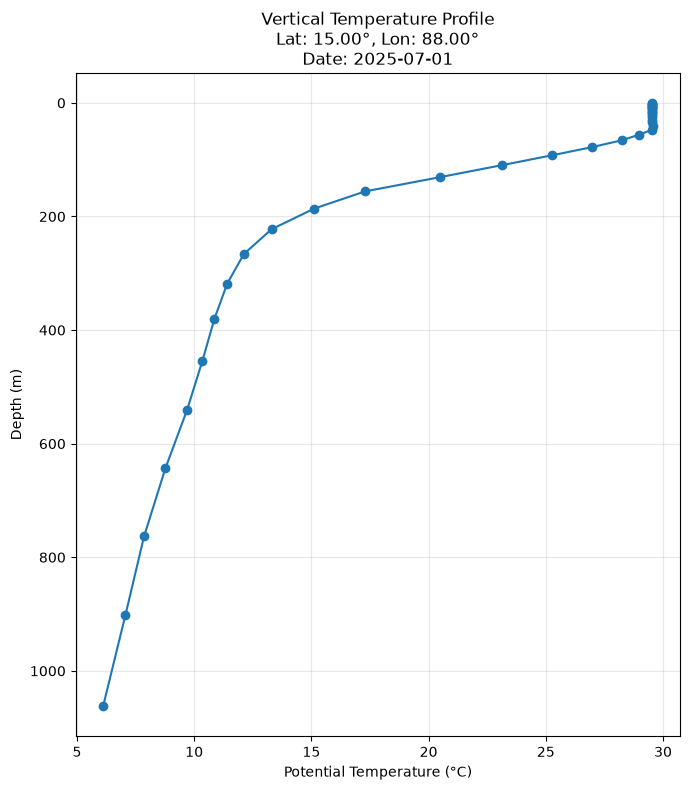

In [8]:
plt.figure(figsize=(7, 8))

plt.plot(
    point_temp.values,
    point_temp.depth.values,
    marker="o"
)

plt.gca().invert_yaxis()

plt.xlabel("Potential Temperature (°C)")
plt.ylabel("Depth (m)")

plt.title(
    f"Vertical Temperature Profile\n"
    f"Lat: {float(point_temp.latitude):.2f}°, "
    f"Lon: {float(point_temp.longitude):.2f}°\n"
    f"Date: {str(ds.time.values[0])[:10]}"
)

plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(
    EDA_DIR / "vertical_temperature_profile_bob.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

In [9]:
target_depths = np.array([
    0, 5, 10, 20, 30,
    50, 75, 100, 125, 150,
    200, 300, 500, 700, 1000
])

native_depths = ds.depth.values

print("Target depth -> nearest native depth")
print("-" * 45)

for target in target_depths:
    idx = np.abs(native_depths - target).argmin()
    native = native_depths[idx]

    print(
        f"{target:6.0f} m -> "
        f"{native:8.3f} m "
        f"(difference: {native-target:+7.3f} m)"
    )

Target depth -> nearest native depth
---------------------------------------------
     0 m ->    0.494 m (difference:  +0.494 m)
     5 m ->    5.078 m (difference:  +0.078 m)
    10 m ->    9.573 m (difference:  -0.427 m)
    20 m ->   18.496 m (difference:  -1.504 m)
    30 m ->   29.445 m (difference:  -0.555 m)
    50 m ->   47.374 m (difference:  -2.626 m)
    75 m ->   77.854 m (difference:  +2.854 m)
   100 m ->   92.326 m (difference:  -7.674 m)
   125 m ->  130.666 m (difference:  +5.666 m)
   150 m ->  155.851 m (difference:  +5.851 m)
   200 m ->  186.126 m (difference: -13.874 m)
   300 m ->  318.127 m (difference: +18.127 m)
   500 m ->  541.089 m (difference: +41.089 m)
   700 m ->  643.567 m (difference: -56.433 m)
  1000 m -> 1062.440 m (difference: +62.440 m)


In [10]:
target_profile = point_temp.interp(
    depth=target_depths
)

# 0 m is outside the native range.
# Replace it with the shallowest native level as our surface proxy.
target_profile.loc[dict(depth=0)] = point_temp.isel(depth=0)

print("Interpolated target-depth profile:")
print("-" * 45)

for depth, temp in zip(
    target_profile.depth.values,
    target_profile.values
):
    print(f"{depth:6.0f} m : {temp:7.2f} °C")

Interpolated target-depth profile:
---------------------------------------------
     0 m :   29.52 °C
     5 m :   29.52 °C
    10 m :   29.52 °C
    20 m :   29.52 °C
    30 m :   29.53 °C
    50 m :   29.36 °C
    75 m :   27.28 °C
   100 m :   24.32 °C
   125 m :   21.21 °C
   150 m :   18.03 °C
   200 m :   14.42 °C
   300 m :   11.66 °C
   500 m :   10.00 °C
   700 m :    8.34 °C
  1000 m :    6.48 °C


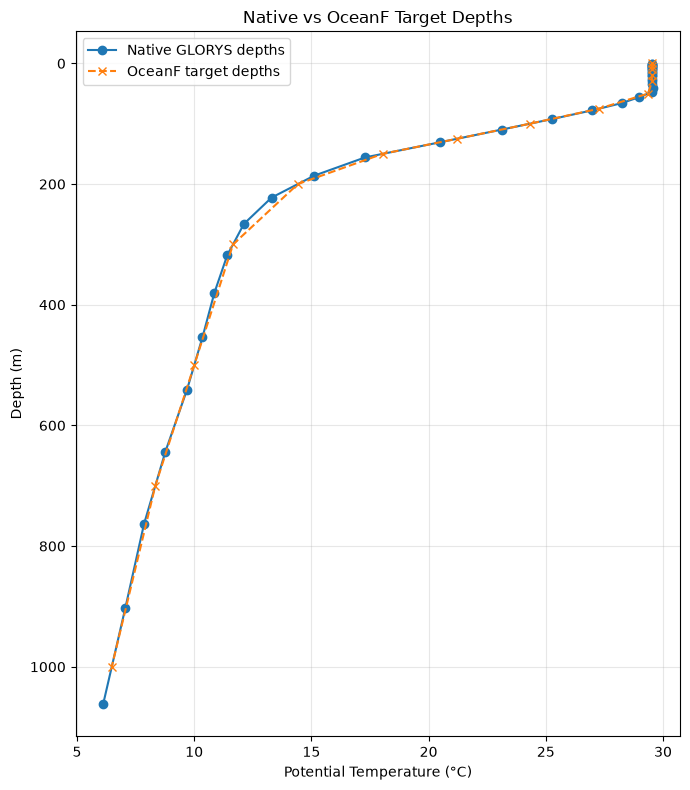

In [11]:
plt.figure(figsize=(7, 8))

plt.plot(
    point_temp.values,
    point_temp.depth.values,
    marker="o",
    label="Native GLORYS depths"
)

plt.plot(
    target_profile.values,
    target_profile.depth.values,
    marker="x",
    linestyle="--",
    label="OceanF target depths"
)

plt.gca().invert_yaxis()

plt.xlabel("Potential Temperature (°C)")
plt.ylabel("Depth (m)")

plt.title("Native vs OceanF Target Depths")

plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()

plt.savefig(
    EDA_DIR / "native_vs_target_depths.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

In [12]:
target_lat = np.arange(5.0, 30.0 + 0.001, 0.25)
target_lon = np.arange(45.0, 105.0 + 0.001, 0.25)

print("Target latitude points:", len(target_lat))
print("Target longitude points:", len(target_lon))

print("\nFirst 10 target latitudes:")
print(target_lat[:10])

print("\nFirst 10 native latitudes:")
print(ds.latitude.values[:10])

print("\nFirst 10 target longitudes:")
print(target_lon[:10])

print("\nFirst 10 native longitudes:")
print(ds.longitude.values[:10])

Target latitude points: 101
Target longitude points: 241

First 10 target latitudes:
[5.   5.25 5.5  5.75 6.   6.25 6.5  6.75 7.   7.25]

First 10 native latitudes:
[5.        5.0833335 5.1666665 5.25      5.3333335 5.4166665 5.5
 5.5833335 5.6666665 5.75     ]

First 10 target longitudes:
[45.   45.25 45.5  45.75 46.   46.25 46.5  46.75 47.   47.25]

First 10 native longitudes:
[45.       45.083332 45.166668 45.25     45.333332 45.416668 45.5
 45.583332 45.666668 45.75    ]


In [13]:
lat_indices = []

for lat in target_lat:
    idx = np.abs(ds.latitude.values - lat).argmin()
    difference = abs(ds.latitude.values[idx] - lat)

    lat_indices.append(idx)

    if difference > 1e-5:
        print(
            f"Latitude mismatch: target={lat}, "
            f"native={ds.latitude.values[idx]}, "
            f"diff={difference}"
        )

lon_indices = []

for lon in target_lon:
    idx = np.abs(ds.longitude.values - lon).argmin()
    difference = abs(ds.longitude.values[idx] - lon)

    lon_indices.append(idx)

    if difference > 1e-5:
        print(
            f"Longitude mismatch: target={lon}, "
            f"native={ds.longitude.values[idx]}, "
            f"diff={difference}"
        )

print("\nLatitude index pattern:")
print(lat_indices[:15])

print("\nLongitude index pattern:")
print(lon_indices[:15])


Latitude index pattern:
[np.int64(0), np.int64(3), np.int64(6), np.int64(9), np.int64(12), np.int64(15), np.int64(18), np.int64(21), np.int64(24), np.int64(27), np.int64(30), np.int64(33), np.int64(36), np.int64(39), np.int64(42)]

Longitude index pattern:
[np.int64(0), np.int64(3), np.int64(6), np.int64(9), np.int64(12), np.int64(15), np.int64(18), np.int64(21), np.int64(24), np.int64(27), np.int64(30), np.int64(33), np.int64(36), np.int64(39), np.int64(42)]


In [14]:
test_surface = thetao.isel(
    time=0,
    depth=0,
    latitude=lat_indices,
    longitude=lon_indices
).load()

print(test_surface)

print("\nShape:", test_surface.shape)
print("Latitude:", test_surface.latitude.values[[0, -1]])
print("Longitude:", test_surface.longitude.values[[0, -1]])

<xarray.DataArray 'thetao' (latitude: 101, longitude: 241)> Size: 195kB
array([[        nan,         nan,         nan, ..., 30.30643634,
        30.21781059, 30.20902126],
       [        nan,         nan,         nan, ..., 30.2229377 ,
        30.17459638, 30.18265327],
       [        nan,         nan,         nan, ..., 30.1218604 ,
        30.15628528, 30.20609149],
       ...,
       [        nan,         nan,         nan, ...,         nan,
                nan,         nan],
       [        nan,         nan,         nan, ...,         nan,
                nan,         nan],
       [        nan,         nan,         nan, ...,         nan,
                nan,         nan]], shape=(101, 241))
Coordinates:
  * latitude   (latitude) float32 404B 5.0 5.25 5.5 5.75 ... 29.5 29.75 30.0
  * longitude  (longitude) float32 964B 45.0 45.25 45.5 ... 104.5 104.8 105.0
    depth      float32 4B 0.494
    time       datetime64[ns] 8B 2025-07-01
Attributes:
    cell_methods:   area: mean
    long_n

In [15]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

PROCESSED_FILE = (
    r"C:\OceanF\data\processed\SubsurfaceTemp"
    r"\SubsurfaceTemp_processed.nc"
)

ds = xr.open_dataset(PROCESSED_FILE)

print(ds)

<xarray.Dataset> Size: 269MB
Dimensions:    (time: 184, depth: 15, latitude: 101, longitude: 241)
Coordinates:
  * time       (time) datetime64[ns] 1kB 2025-07-01 2025-07-02 ... 2025-12-31
  * depth      (depth) float64 120B 0.0 5.0 10.0 20.0 ... 500.0 700.0 1e+03
  * latitude   (latitude) float32 404B 5.0 5.25 5.5 5.75 ... 29.5 29.75 30.0
  * longitude  (longitude) float32 964B 45.0 45.25 45.5 ... 104.5 104.8 105.0
Data variables:
    thetao     (time, depth, latitude, longitude) float32 269MB ...
Attributes: (12/18)
    title:                OceanF North Indian Ocean Daily Subsurface Temperat...
    project:              OceanF
    description:          Daily subsurface ocean potential temperature over t...
    source:               MERCATOR GLORYS12V1
    source_variable:      thetao
    domain:               North Indian Ocean
    ...                   ...
    vertical_method:      Linear interpolation from native GLORYS depth levels
    surface_method:       Shallowest native leve

In [16]:
print("Dimensions:")
for dim, size in ds.sizes.items():
    print(f"{dim:10s}: {size}")

assert ds.sizes["time"] == 184
assert ds.sizes["depth"] == 15
assert ds.sizes["latitude"] == 101
assert ds.sizes["longitude"] == 241

print("\nDimension verification PASSED")

Dimensions:
time      : 184
depth     : 15
latitude  : 101
longitude : 241

Dimension verification PASSED


In [17]:
expected_depths = np.array([
    0, 5, 10, 20, 30, 50, 75, 100,
    125, 150, 200, 300, 500, 700, 1000
])

print("Processed depths:")
print(ds.depth.values)

assert np.allclose(
    ds.depth.values,
    expected_depths,
    atol=1e-5
)

print("\nDepth verification PASSED")

Processed depths:
[   0.    5.   10.   20.   30.   50.   75.  100.  125.  150.  200.  300.
  500.  700. 1000.]

Depth verification PASSED


In [18]:
lat = ds.latitude.values
lon = ds.longitude.values

print(f"Latitude : {lat.min()} → {lat.max()}")
print(f"Longitude: {lon.min()} → {lon.max()}")

print(f"Latitude spacing : {np.unique(np.round(np.diff(lat), 6))}")
print(f"Longitude spacing: {np.unique(np.round(np.diff(lon), 6))}")

assert np.isclose(lat.min(), 5)
assert np.isclose(lat.max(), 30)
assert np.isclose(lon.min(), 45)
assert np.isclose(lon.max(), 105)

assert np.allclose(np.diff(lat), 0.25, atol=1e-5)
assert np.allclose(np.diff(lon), 0.25, atol=1e-5)

print("\nSpatial grid verification PASSED")

Latitude : 5.0 → 30.0
Longitude: 45.0 → 105.0
Latitude spacing : [0.25]
Longitude spacing: [0.25]

Spatial grid verification PASSED


In [19]:
time = ds.time.values

print("Start:", time[0])
print("End  :", time[-1])
print("Count:", len(time))

time_diff = np.diff(time).astype("timedelta64[D]")

assert np.all(time_diff == np.timedelta64(1, "D"))

print("\nTime verification PASSED")

Start: 2025-07-01T00:00:00.000000000
End  : 2025-12-31T00:00:00.000000000
Count: 184

Time verification PASSED


In [20]:
thetao = ds.thetao

print("Temperature variable:")
print(thetao)

print("\nLoading statistics...")

for depth in expected_depths:
    data = thetao.sel(depth=depth).values

    finite = data[np.isfinite(data)]

    if finite.size > 0:
        print(
            f"{depth:5.0f} m | "
            f"min={finite.min():7.2f} °C | "
            f"max={finite.max():7.2f} °C | "
            f"mean={finite.mean():7.2f} °C"
        )
    else:
        print(f"{depth:5.0f} m | ALL NaN")

Temperature variable:
<xarray.DataArray 'thetao' (time: 184, depth: 15, latitude: 101, longitude: 241)> Size: 269MB
[67181160 values with dtype=float32]
Coordinates:
  * time       (time) datetime64[ns] 1kB 2025-07-01 2025-07-02 ... 2025-12-31
  * depth      (depth) float64 120B 0.0 5.0 10.0 20.0 ... 500.0 700.0 1e+03
  * latitude   (latitude) float32 404B 5.0 5.25 5.5 5.75 ... 29.5 29.75 30.0
  * longitude  (longitude) float32 964B 45.0 45.25 45.5 ... 104.5 104.8 105.0
Attributes:
    long_name:               Subsurface sea water potential temperature
    standard_name:           sea_water_potential_temperature
    units:                   degrees_C
    description:             Daily subsurface ocean potential temperature rec...
    vertical_interpolation:  Linear interpolation
    surface_proxy_depth_m:   0.49402499198913574
    spatial_method:          Exact native-grid point selection at 0.25 degree...

Loading statistics...
    0 m | min=  18.16 °C | max=  36.09 °C | mean=  28.47 

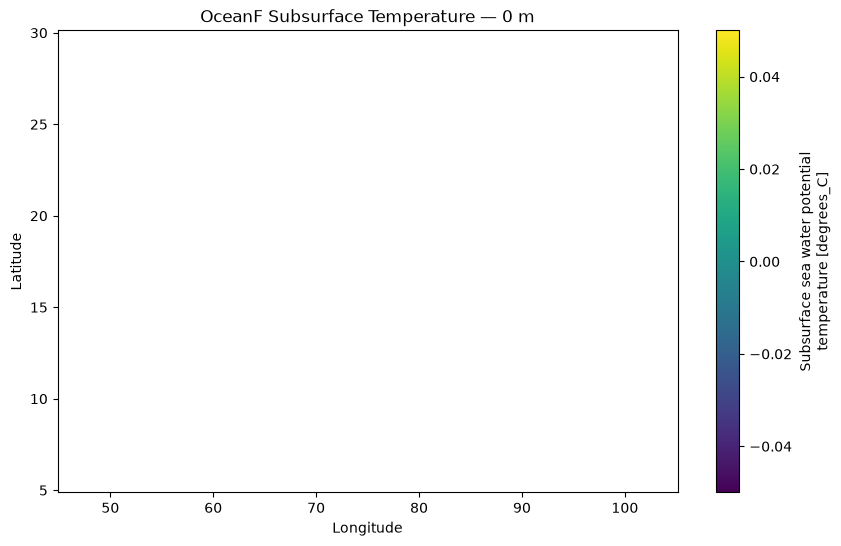

In [22]:
plt.figure(figsize=(10, 6))

thetao.sel(
    depth=0,
    time=thetao.time[0]
).plot()

plt.title("OceanF Subsurface Temperature — 0 m")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

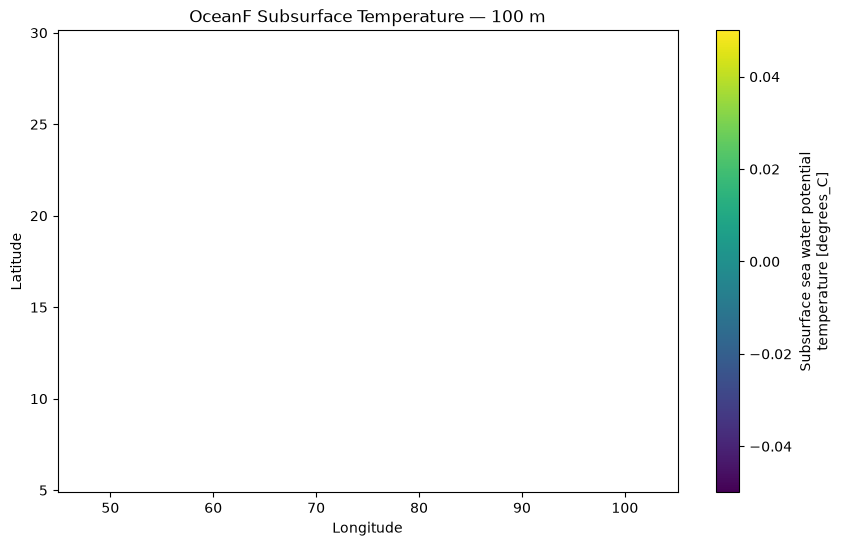

In [23]:
plt.figure(figsize=(10, 6))

thetao.sel(
    depth=100,
    time=thetao.time[0]
).plot()

plt.title("OceanF Subsurface Temperature — 100 m")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

In [1]:
import xarray as xr
import numpy as np

PROCESSED_FILE = (
    r"C:\OceanF\data\processed\SubsurfaceTemp"
    r"\SubsurfaceTemp_processed.nc"
)

ds = xr.open_dataset(PROCESSED_FILE)

print(ds)

<xarray.Dataset> Size: 269MB
Dimensions:    (time: 184, depth: 15, latitude: 101, longitude: 241)
Coordinates:
  * time       (time) datetime64[ns] 1kB 2025-07-01 2025-07-02 ... 2025-12-31
  * depth      (depth) float64 120B 0.0 5.0 10.0 20.0 ... 500.0 700.0 1e+03
  * latitude   (latitude) float32 404B 5.0 5.25 5.5 5.75 ... 29.5 29.75 30.0
  * longitude  (longitude) float32 964B 45.0 45.25 45.5 ... 104.5 104.8 105.0
Data variables:
    thetao     (time, depth, latitude, longitude) float32 269MB ...
Attributes: (12/18)
    title:                OceanF North Indian Ocean Daily Subsurface Temperat...
    project:              OceanF
    description:          Daily subsurface ocean potential temperature over t...
    source:               MERCATOR GLORYS12V1
    source_variable:      thetao
    domain:               North Indian Ocean
    ...                   ...
    vertical_method:      Linear interpolation from native GLORYS depth levels
    surface_method:       Shallowest native leve

In [2]:
thetao = ds["thetao"]

print("Shape:", thetao.shape)
print("Dtype:", thetao.dtype)

print("\nChecking first day...")

data = thetao.isel(time=0).values

finite = data[np.isfinite(data)]

print("Finite values:", finite.size)
print("Total values :", data.size)

if finite.size > 0:
    print("Minimum:", finite.min())
    print("Maximum:", finite.max())
    print("Mean   :", finite.mean())
else:
    print("WARNING: ALL VALUES ARE NaN")

Shape: (184, 15, 101, 241)
Dtype: float32

Checking first day...
Finite values: 156043
Total values : 365115
Minimum: 5.537368
Maximum: 34.520187
Mean   : 22.035471


In [3]:
for depth in ds.depth.values:

    data = ds.thetao.sel(depth=depth).values

    finite = data[np.isfinite(data)]

    if finite.size == 0:
        print(f"{depth:7.1f} m : ALL NaN")
    else:
        print(
            f"{depth:7.1f} m : "
            f"min={finite.min():.2f}, "
            f"max={finite.max():.2f}, "
            f"mean={finite.mean():.2f}, "
            f"valid={finite.size}"
        )

    0.0 m : min=16.05, max=36.29, mean=28.32, valid=2214992
    5.0 m : min=16.20, max=36.16, mean=28.29, valid=2214992
   10.0 m : min=17.12, max=35.83, mean=28.26, valid=2151880
   20.0 m : min=15.44, max=35.52, mean=28.17, valid=2100728
   30.0 m : min=14.87, max=34.76, mean=27.97, valid=2040376
   50.0 m : min=14.12, max=33.33, mean=27.29, valid=1952976
   75.0 m : min=13.27, max=32.18, mean=25.93, valid=1874960
  100.0 m : min=12.43, max=30.84, mean=23.77, valid=1826936
  125.0 m : min=11.11, max=28.91, mean=21.13, valid=1816816
  150.0 m : min=10.86, max=28.53, mean=18.76, valid=1805592
  200.0 m : min=10.23, max=25.56, mean=15.78, valid=1789032
  300.0 m : min=9.63, max=20.60, mean=13.09, valid=1773760
  500.0 m : min=9.05, max=16.65, mean=11.20, valid=1744320
  700.0 m : min=7.45, max=14.30, mean=9.75, valid=1722792
 1000.0 m : min=5.11, max=12.47, mean=7.69, valid=1681760


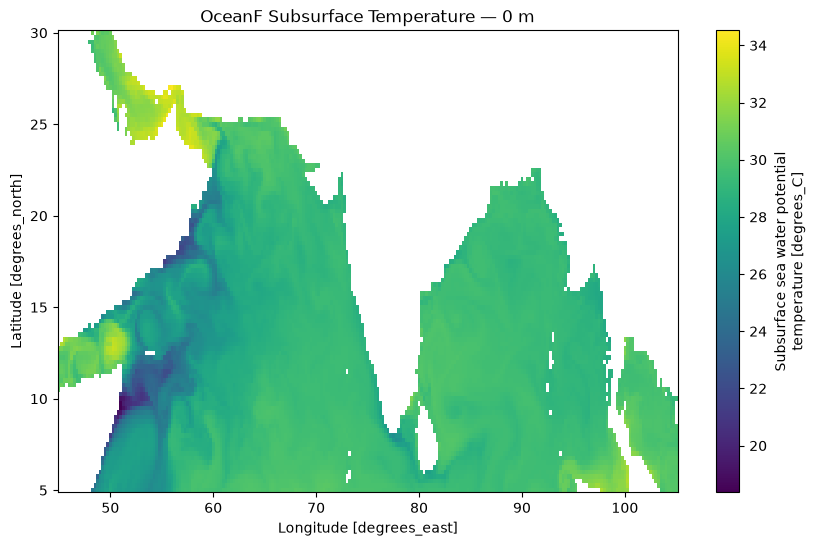

In [4]:
import matplotlib.pyplot as plt

thetao.sel(
    depth=0,
    time=ds.time[0]
).plot(figsize=(10, 6))

plt.title("OceanF Subsurface Temperature — 0 m")
plt.show()